<a href="https://colab.research.google.com/github/rakeshmn97/ExploratoryDataAnalysis/blob/main/Loan_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [4]:
loan=pd.read_csv('/content/drive/MyDrive/Aiml Datasets/Loan Prediction.csv')

In [5]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
loan.info()
loan.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
print (loan.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


###EDA

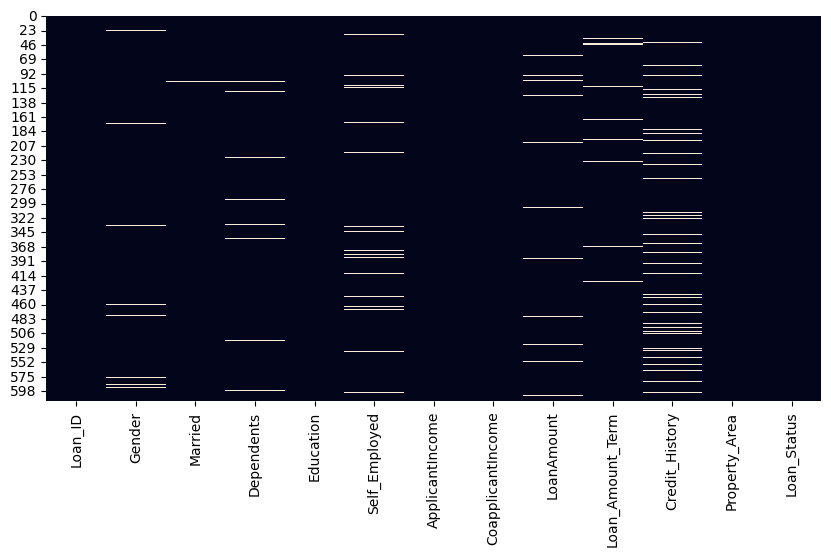

In [8]:
plt.figure(figsize=(10,5))
sns.heatmap(loan.isnull(), cbar=False)
plt.show()

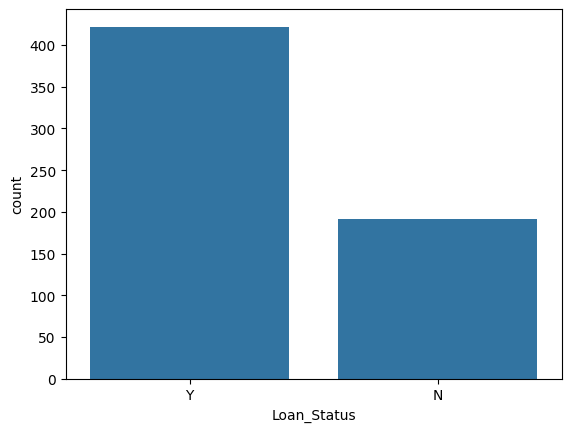

In [9]:
sns.countplot(x="Loan_Status", data=loan)
plt.show()

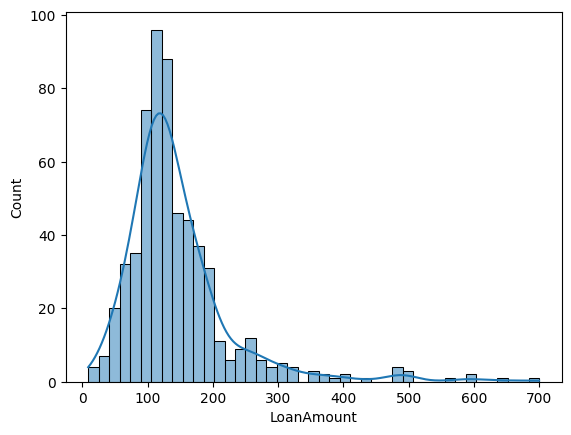

In [10]:
sns.histplot(loan["LoanAmount"], kde=True)
plt.show()

### Data Preprocessing

In [11]:
for col in ['Gender','Married','Dependents','Self_Employed']:
    loan[col] = loan[col].fillna(loan[col].mode()[0])

loan['LoanAmount'] = loan['LoanAmount'].fillna(loan['LoanAmount'].median())

loan['Loan_Amount_Term'] = loan['Loan_Amount_Term'].fillna(loan['Loan_Amount_Term'].mode()[0])

loan['Credit_History'] = loan['Credit_History'].fillna(loan['Credit_History'].mode()[0])

In [14]:
loan.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Loan_Status'
]

for col in categorical_cols:
    loan[col] = le.fit_transform(loan[col])

In [18]:
loan['Dependents'] = loan['Dependents'].replace('3+', '3')
loan['Dependents'] = le.fit_transform(loan['Dependents'])

In [19]:
loan = pd.get_dummies(
    loan,
    columns=['Property_Area'],
    drop_first=True,
    dtype=int
)

In [20]:
print(loan.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status',
       'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='object')


In [21]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  614 non-null    object 
 1   Gender                   614 non-null    int64  
 2   Married                  614 non-null    int64  
 3   Dependents               614 non-null    int64  
 4   Education                614 non-null    int64  
 5   Self_Employed            614 non-null    int64  
 6   ApplicantIncome          614 non-null    int64  
 7   CoapplicantIncome        614 non-null    float64
 8   LoanAmount               614 non-null    float64
 9   Loan_Amount_Term         614 non-null    float64
 10  Credit_History           614 non-null    float64
 11  Loan_Status              614 non-null    int64  
 12  Property_Area_Semiurban  614 non-null    int64  
 13  Property_Area_Urban      614 non-null    int64  
dtypes: float64(4), int64(9), o

In [22]:
loan.drop('Loan_ID',axis=1,inplace=True)

In [23]:
loan.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


### Logistic Regression - Loan Prediction

In [24]:
X = loan.drop('Loan_Status', axis=1)

y = loan['Loan_Status']

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=101
)

In [26]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [27]:
y_pred = log_model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.7783783783783784


##Linear Regression- loan amount prediction

In [31]:
X2 = loan.drop(['LoanAmount', 'Loan_Status'], axis=1)

y2 = loan['LoanAmount']

In [32]:
from sklearn.model_selection import train_test_split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.3,
    random_state=101
)

In [33]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()

lm.fit(X2_train, y2_train)

LinearRegression()

In [35]:
loan_pred = lm.predict(X2_test)

In [38]:
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y2_test, loan_pred))
print('MSE:', metrics.mean_squared_error(y2_test, loan_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y2_test, loan_pred)))
print("R2 Score:",metrics.r2_score(y2_test, loan_pred))

MAE: 42.2768159624738
MSE: 4455.87675722077
RMSE: 66.75235394516638
R2 Score: 0.30728405639598655


In [40]:
print("Coiefficent:",lm.coef_)
print("Intercept:",lm.intercept_)

Coiefficent: [-9.11371541e+00  2.28198830e+01  1.03037581e+01 -1.59076638e+01
  1.43928267e+01  6.83213243e-03  6.68560401e-03  8.96700328e-02
 -1.23523298e+00 -8.74769823e+00 -1.14480229e+01]
Intercept: 60.8331796175369


### Examples for Loan Amount Prediction


In [45]:
new_customer = [[
    1,
    1,
    2,
    1,
    0,
    7000,
    3000,
    360,
    1,
    1,
    0
]]

loan_amount = lm.predict(new_customer)

print(loan_amount)

[169.41921927]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Example for loan prediction

In [46]:
new_applicant = [[
    1,      # Gender
    1,      # Married
    1,      # Dependents
    1,      # Education
    0,      # Self_Employed
    5000,   # ApplicantIncome
    2000,   # CoapplicantIncome
    150,    # LoanAmount
    360,    # Loan_Amount_Term
    1,      # Credit_History
    1,      # Property_Area_Semiurban
    0       # Property_Area_Urban
]]

loan_status = log_model.predict(new_applicant)

if loan_status[0] == 1:
    print("The applicant is eligible for a loan.")
else:
    print("The applicant is not eligible for a loan.")

The applicant is eligible for a loan.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
